# Face Recognition with MTCNN + FaceNet

**Pipeline:** MTCNN (face detection) → FaceNet (512-d face embedding) → small Keras classifier (105 celebrities).

> ⚠️ Educational project. Uses public celebrity images only. Face data is biometric data: do not use this to identify private people without their consent.

**How to run (Google Colab):** `Runtime → Change runtime type → GPU (T4)`, then `Runtime → Run all`.
The only manual step is uploading your `kaggle.json` when asked (Kaggle → Settings → API → *Create New Token*).
First run takes roughly 20–40 minutes (mostly face detection); later runs reuse cached files.

## 1. Settings & install

In [1]:
# Install (Colab already has TensorFlow). If you get an import error afterwards: Runtime -> Restart session, then Run all.
!pip install -q keras-facenet mtcnn split-folders kaggle tqdm

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 22.8 MB/s eta 0:00:00


In [2]:
# ===== Settings: change here only =====
N_TRAIN_PER_CLASS = 50     # images per person used for training (dataset has ~140 per person)
N_VAL_PER_CLASS   = 10     # images per person for validation (early stopping)
N_TEST_PER_CLASS  = 10     # images per person for the final test
UNKNOWN_THRESHOLD = 0.60   # below this confidence the answer is "unknown"
SEED = 42
ONLY_FIRST_N_CLASSES = None   # e.g. 5 for a quick smoke test (~2 minutes); None = all 105 people

import os, sys, json, time, random, shutil, zipfile, subprocess, contextlib, io
import numpy as np
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

random.seed(SEED); np.random.seed(SEED)
IN_COLAB = 'google.colab' in sys.modules
RAW_DIR, DATA_DIR = '105_classes_pins_dataset', 'pins_dataset'

## 2. Download the dataset and split it
Dataset: [Pins Face Recognition (Kaggle)](https://www.kaggle.com/datasets/hereisburak/pins-face-recognition).
`split-folders` creates `train/`, `val/`, `test/` folders (val and test get a fixed number of images per person, all remaining images go to `train`).

In [3]:
KAGGLE_JSON = os.path.expanduser('~/.kaggle/kaggle.json')

if not os.path.isdir(DATA_DIR):
    if not os.path.isdir(RAW_DIR):
        if not os.path.exists(KAGGLE_JSON) and not os.environ.get('KAGGLE_USERNAME'):
            if not IN_COLAB:
                raise RuntimeError('Put your kaggle.json in ~/.kaggle/ first.')
            from google.colab import files
            print('Upload your kaggle.json:')
            files.upload()
            os.makedirs(os.path.dirname(KAGGLE_JSON), exist_ok=True)
            shutil.copy('kaggle.json', KAGGLE_JSON)
            os.chmod(KAGGLE_JSON, 0o600)
        subprocess.run(['kaggle', 'datasets', 'download', '-d', 'hereisburak/pins-face-recognition'], check=True)
        with zipfile.ZipFile('pins-face-recognition.zip') as z:
            z.extractall('.')
    import splitfolders
    splitfolders.fixed(input=RAW_DIR, output=DATA_DIR, seed=SEED, fixed=(N_VAL_PER_CLASS, N_TEST_PER_CLASS))

# sanity check on the split
some_class = sorted(os.listdir(os.path.join(DATA_DIR, 'test')))[0]
for split in ['train', 'val', 'test']:
    print(split, len(os.listdir(os.path.join(DATA_DIR, split, some_class))), 'images for', some_class)

Upload your kaggle.json:


Saving kaggle.json to kaggle.json


Copying files: 17534 files [00:02, 5892.42 files/s]

train 193 images for pins_Adriana Lima
val 10 images for pins_Adriana Lima
test 10 images for pins_Adriana Lima


## 3. Face detection (MTCNN)
For each image the **largest** detected face is cropped and resized to 160×160. Images where no face is found (or where MTCNN fails) are skipped and counted.
Results are cached in `faces-only-dataset.npz` and reused as long as the settings (images per person, seed, number of classes) stay the same, so re-running is fast.

In [5]:
from mtcnn import MTCNN
detector = MTCNN()          # created ONCE (creating it per image is very slow)
IMG_EXT = ('.jpg', '.jpeg', '.png', '.jfif', '.bmp', '.webp')

def extract_face(path, required_size=(160, 160)):
    image = Image.open(path).convert('RGB')
    pixels = np.asarray(image)
    try:
        faces = detector.detect_faces(pixels)
    except Exception:
        return None
    if len(faces) == 0:
        return None
    best = max(faces, key=lambda f: f['box'][2] * f['box'][3])
    x1, y1, w, h = best['box']
    x1, y1 = max(0, x1), max(0, y1)
    face = Image.fromarray(pixels[y1:y1 + h, x1:x1 + w]).resize(required_size)
    return np.asarray(face)

def load_split(split, per_class, classes):
    X, y, skipped = [], [], 0
    for cls in tqdm(classes, desc=split):
        folder = os.path.join(DATA_DIR, split, cls)
        files = sorted(f for f in os.listdir(folder) if f.lower().endswith(IMG_EXT))[:per_class]
        for f in files:
            face = extract_face(os.path.join(folder, f))
            if face is None:
                skipped += 1
                continue
            X.append(face); y.append(cls.replace('pins_', ''))
    print(f'{split}: {len(X)} faces, {skipped} images without a detected face')
    return np.asarray(X, dtype=np.uint8), np.asarray(y)

CONFIG_KEY = f'{N_TRAIN_PER_CLASS}-{N_VAL_PER_CLASS}-{N_TEST_PER_CLASS}-{ONLY_FIRST_N_CLASSES}-{SEED}'
FACES_FILE = 'faces-only-dataset.npz'

cached = None
if os.path.exists(FACES_FILE):
    d = np.load(FACES_FILE, allow_pickle=False)
    if str(d['config']) == CONFIG_KEY:
        cached = d
if cached is not None:
    print('Using cached faces file.')
    train_faces, train_y, val_faces, val_y, test_faces, test_y = [cached[k] for k in
        ['train_X', 'train_y', 'val_X', 'val_y', 'test_X', 'test_y']]
else:
    classes = sorted(os.listdir(os.path.join(DATA_DIR, 'test')))
    if ONLY_FIRST_N_CLASSES:
        classes = classes[:ONLY_FIRST_N_CLASSES]
    train_faces, train_y = load_split('train', N_TRAIN_PER_CLASS, classes)
    val_faces,   val_y   = load_split('val',   N_VAL_PER_CLASS,   classes)
    test_faces,  test_y  = load_split('test',  N_TEST_PER_CLASS,  classes)
    np.savez_compressed(FACES_FILE, config=CONFIG_KEY, train_X=train_faces, train_y=train_y,
                        val_X=val_faces, val_y=val_y, test_X=test_faces, test_y=test_y)

print(train_faces.shape, val_faces.shape, test_faces.shape)

Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/lz4/frame/__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/lz4/frame/__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/lz4/frame/__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.


train:   0%|          | 0/105 [00:00<?, ?it/s]

train: 5209 faces, 41 images without a detected face


val:   0%|          | 0/105 [00:00<?, ?it/s]

val: 1044 faces, 6 images without a detected face


test:   0%|          | 0/105 [00:00<?, ?it/s]

test: 1044 faces, 6 images without a detected face
(5209, 160, 160, 3) (1044, 160, 160, 3) (1044, 160, 160, 3)


## 4. Face embeddings (FaceNet)
FaceNet turns each 160×160 face into a 512-number vector. Faces of the same person end up close together.
We L2-normalize the vectors (standard practice for FaceNet) before classification.

In [6]:
from keras_facenet import FaceNet
facenet = FaceNet()

def get_embeddings(faces, chunk=256):
    out = []
    for i in tqdm(range(0, len(faces), chunk), desc='embedding'):
        with contextlib.redirect_stdout(io.StringIO()):       # hide Keras progress bars
            out.append(facenet.embeddings(faces[i:i + chunk]))
    emb = np.concatenate(out).astype('float32')
    return emb / np.linalg.norm(emb, axis=1, keepdims=True)  # L2 normalization

EMB_FILE = 'faces-embeddings.npz'
if os.path.exists(EMB_FILE) and str(np.load(EMB_FILE)['config']) == CONFIG_KEY:
    e = np.load(EMB_FILE)
    train_X, val_X, test_X = e['train_X'], e['val_X'], e['test_X']
    print('Using cached embeddings.')
else:
    train_X, val_X, test_X = get_embeddings(train_faces), get_embeddings(val_faces), get_embeddings(test_faces)
    np.savez_compressed(EMB_FILE, config=CONFIG_KEY, train_X=train_X, val_X=val_X, test_X=test_X)
print(train_X.shape, val_X.shape, test_X.shape)

embedding:   0%|          | 0/21 [00:00<?, ?it/s]

embedding:   0%|          | 0/5 [00:00<?, ?it/s]

embedding:   0%|          | 0/5 [00:00<?, ?it/s]

(5209, 512) (1044, 512) (1044, 512)


## 5. Train the classifier
A small neural network on top of the embeddings. **Dropout** and **early stopping on the validation set** reduce overfitting
(the original version reached 100% train vs ~93% test accuracy).

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 105)            │        13,545 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,209 (309.41 KB)

 Trainable params: 79,209 (309.41 KB)

 Non-trainable params: 0 (0.00 B)

Stopped after 50 epochs
train accuracy: 100.00%
val   accuracy: 98.75%
test  accuracy: 98.37%


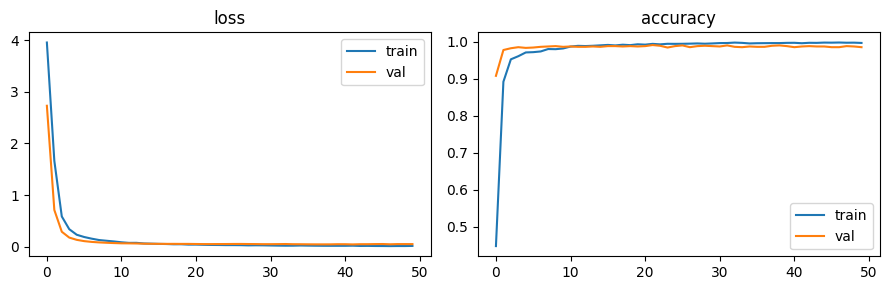

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import LabelEncoder

tf.keras.utils.set_random_seed(SEED)
encoder = LabelEncoder().fit(train_y)
label_classes = list(encoder.classes_)
n_classes = len(label_classes)
train_t, val_t, test_t = (encoder.transform(a) for a in (train_y, val_y, test_y))

clf = models.Sequential([
    layers.Input(shape=(train_X.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(n_classes, activation='softmax'),
])
clf.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
clf.summary()

history = clf.fit(
    train_X, train_t, validation_data=(val_X, val_t),
    epochs=100, batch_size=32, verbose=0,
    callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)],
)
print('Stopped after', len(history.history['loss']), 'epochs')

for name, X, t in [('train', train_X, train_t), ('val', val_X, val_t), ('test', test_X, test_t)]:
    _, acc = clf.evaluate(X, t, verbose=0)
    print(f'{name:5s} accuracy: {acc * 100:.2f}%')

plt.figure(figsize=(9, 3))
plt.subplot(1, 2, 1); plt.plot(history.history['loss'], label='train'); plt.plot(history.history['val_loss'], label='val'); plt.title('loss'); plt.legend()
plt.subplot(1, 2, 2); plt.plot(history.history['accuracy'], label='train'); plt.plot(history.history['val_accuracy'], label='val'); plt.title('accuracy'); plt.legend()
plt.tight_layout(); plt.show()

## 6. Evaluation on the test set
Confusion matrix, the most confused pairs of people, and the effect of the "unknown" threshold.

Test accuracy: 98.37%   macro-F1: 0.983


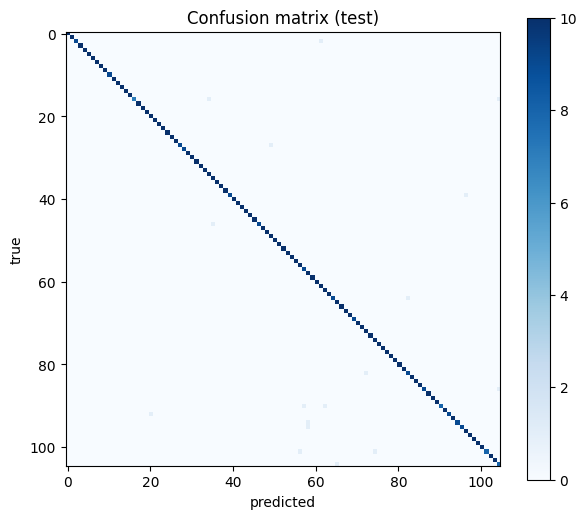


Most confused pairs (true -> predicted):
  amber heard -> Miley Cyrus: 1 times
  Chris Hemsworth -> tom ellis: 1 times
  Johnny Depp -> elon musk: 1 times
  Tom Holland -> Robert Downey Jr: 1 times
  elizabeth olsen -> Millie Bobby Brown: 1 times
  tom ellis -> Pedro Alonso: 1 times
  barbara palvin -> Danielle Panabaker: 1 times
  Chris Hemsworth -> Jason Momoa: 1 times

Unknown threshold: coverage vs accuracy of accepted answers
  threshold 0.3: answered 100.0% of faces, accuracy of those  98.4%
  threshold 0.5: answered  99.5% of faces, accuracy of those  98.7%
  threshold 0.6: answered  99.1% of faces, accuracy of those  99.0%
  threshold 0.7: answered  98.3% of faces, accuracy of those  99.4%
  threshold 0.8: answered  97.6% of faces, accuracy of those  99.5%
  threshold 0.9: answered  96.1% of faces, accuracy of those  99.6%


In [8]:
from sklearn.metrics import confusion_matrix, f1_score
test_prob = clf.predict(test_X, verbose=0)
test_pred = test_prob.argmax(axis=1)
print(f'Test accuracy: {(test_pred == test_t).mean() * 100:.2f}%   macro-F1: {f1_score(test_t, test_pred, average="macro"):.3f}')

cm = confusion_matrix(test_t, test_pred, labels=range(n_classes))
plt.figure(figsize=(7, 6)); plt.imshow(cm, cmap='Blues'); plt.colorbar()
plt.title('Confusion matrix (test)'); plt.xlabel('predicted'); plt.ylabel('true'); plt.show()

off = cm.copy(); np.fill_diagonal(off, 0)
print('\nMost confused pairs (true -> predicted):')
for idx in np.argsort(off, axis=None)[::-1][:8]:
    i, j = divmod(idx, n_classes)
    if off[i, j] > 0:
        print(f'  {label_classes[i]} -> {label_classes[j]}: {off[i, j]} times')

print('\nUnknown threshold: coverage vs accuracy of accepted answers')
conf = test_prob.max(axis=1)
for th in [0.3, 0.5, 0.6, 0.7, 0.8, 0.9]:
    accepted = conf >= th
    acc = (test_pred[accepted] == test_t[accepted]).mean() * 100 if accepted.any() else float('nan')
    print(f'  threshold {th:.1f}: answered {accepted.mean() * 100:5.1f}% of faces, accuracy of those {acc:5.1f}%')

## 7. Try a random test example

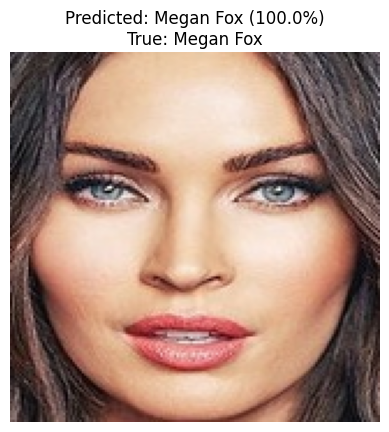

Megan Fox                 100.00%
Tom Hardy                   0.00%
Lindsey Morgan              0.00%
Sophie Turner               0.00%
Irina Shayk                 0.00%


In [9]:
i = random.randrange(len(test_X))
prob = clf.predict(test_X[i:i + 1], verbose=0)[0]
top = np.argsort(-prob)[:5]
plt.imshow(test_faces[i]); plt.axis('off')
plt.title(f'Predicted: {label_classes[top[0]]} ({prob[top[0]] * 100:.1f}%)\nTrue: {test_y[i]}'); plt.show()
for k in top:
    print(f'{label_classes[k]:25s} {prob[k] * 100:6.2f}%')

## 8. Save the model
Everything needed for inference is saved next to the notebook (download these files from the Colab file browser if you want to keep them).

In [10]:
clf.save('face_classifier.keras')
with open('label_classes.json', 'w') as f:
    json.dump(label_classes, f)
print('Saved: face_classifier.keras, label_classes.json')

Saved: face_classifier.keras, label_classes.json


## 9. Recognize a new photo
Upload a photo (Colab) or set `IMAGE_PATH`. The model only knows the people in the dataset: if the confidence is below `UNKNOWN_THRESHOLD`, it answers "unknown".

In [ ]:
centroids = np.stack([train_X[train_t == k].mean(axis=0) for k in range(n_classes)])
centroids /= np.linalg.norm(centroids, axis=1, keepdims=True)
val_sim = (val_X @ centroids.T).max(axis=1)
SIM_THRESHOLD = float(np.percentile(val_sim, 5))     # accepts ~95% of known faces
print(f'SIM_THRESHOLD = {SIM_THRESHOLD:.3f}')

def recognize(image_path, top_k=5, show=True):
    face = extract_face(image_path)
    if face is None:
        print('No face detected in this image.')
        return None
    emb = get_embeddings(face[None], chunk=1)
    prob = clf.predict(emb, verbose=0)[0]
    sims = (emb @ centroids.T)[0]
    top = np.argsort(-prob)[:top_k]
    best = int(top[0])
    known = prob[best] >= UNKNOWN_THRESHOLD and sims[best] >= SIM_THRESHOLD
    answer = label_classes[best] if known else 'unknown'
    if show:
        plt.imshow(face); plt.axis('off')
        plt.title(f'{answer}  (prob {prob[best]*100:.0f}%, similarity {sims[best]:.2f})'); plt.show()
        for k in top:
            print(f'{label_classes[k]:25s} {prob[k] * 100:6.2f}%   similarity {sims[k]:.2f}')
    return answer

IMAGE_PATH = None        # e.g. 'my_photo.jpg'
if IMAGE_PATH is None and IN_COLAB:
    from google.colab import files
    up = files.upload()
    IMAGE_PATH = next(iter(up)) if up else None
if IMAGE_PATH:
    recognize(IMAGE_PATH)

## Known limitations
- Works best with one clear, front-facing face; the largest detected face is used.
- Only knows the 105 people in the dataset. The threshold reduces, but does not remove, wrong answers for strangers.
- Accuracy depends on `N_TRAIN_PER_CLASS`; more images per person usually means better accuracy but a longer first run.
- Uses `keras-facenet` (FaceNet trained on MS-Celeb-1M-style data) – check its license before commercial use.